=== Loading TIFFs ===
=== Propagating (ASM padded) ===


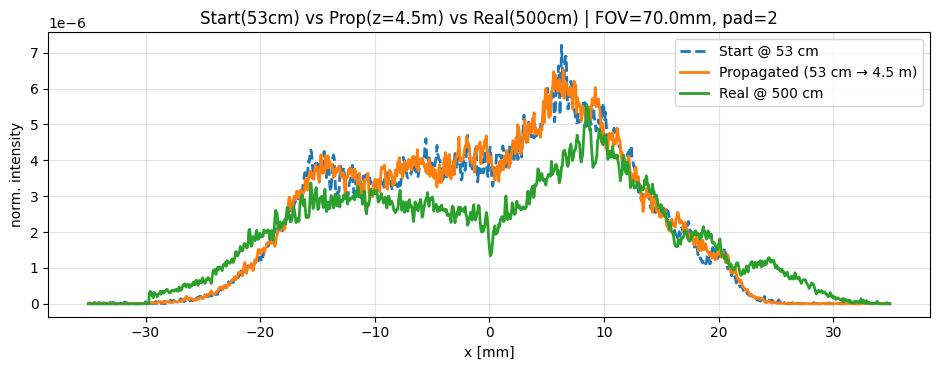

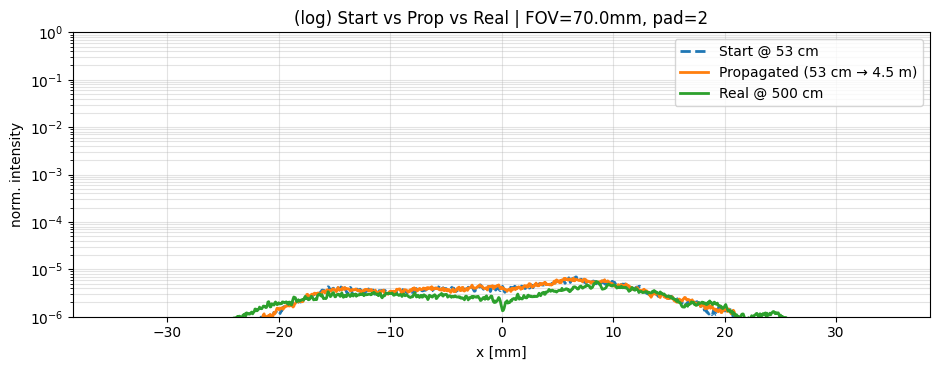

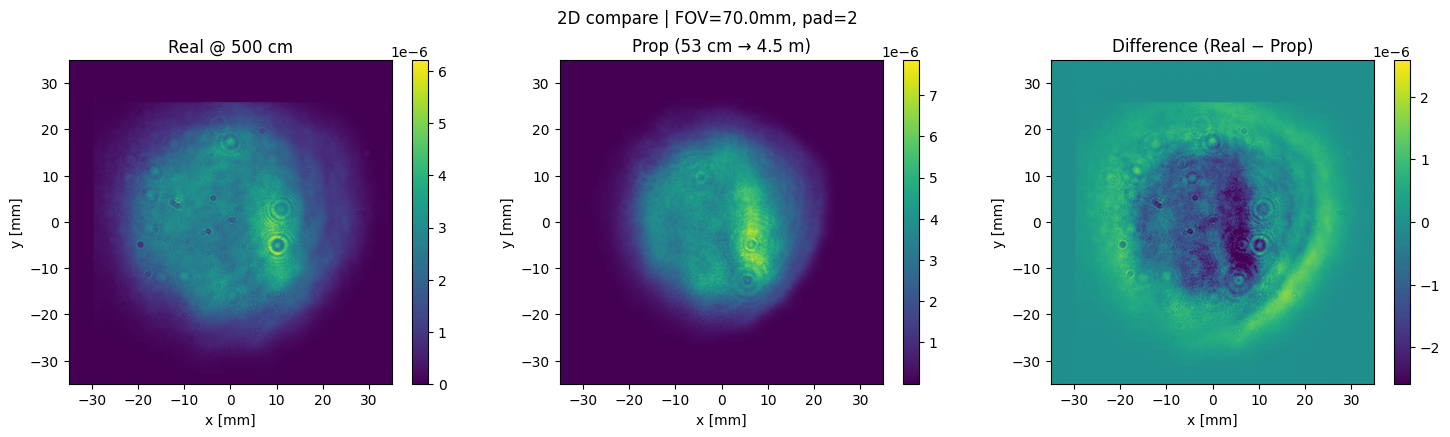


=== Difference Metrics (power-normalized intensities) ===
[All pixels]
  MAE   : 3.84281e-07
  RMSE  : 6.36143e-07
  NRMSE : 0.10241
  Corr  : 0.928184

[Beam mask: I_real > 0.01 * max(I_real)]
  MAE   : 6.14535e-07
  RMSE  : 8.08462e-07
  NRMSE : 0.131467
  Corr  : 0.921317

Extra:
  Mean(|Real-Prop|): 3.84281e-07
  Max(|Real-Prop|) : 5.07741e-06

NOTE:
  If the match is still poor, the main missing piece is phase (wavefront curvature/aberrations).
  But getting FOV_MM correct and using padding usually improves things a lot.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os

# ==============================================================
# CONFIG
# ==============================================================
LAM = 800e-9                 # wavelength [m]
N = 1024                     # simulation grid size (NxN)
FOV_MM = 70.0                # <-- SET THIS: real camera field-of-view width in mm!
PAD_FACTOR = 2               # 2 or 4 recommended

FILE_53CM  = "messung 53cm.tiff"
FILE_500CM = "messung 500cm.tiff"
Z_PROP = 4.5                 # propagate 53cm -> +4.5 m ~ 500 cm

# Options
CENTER_IMAGES = True
SUBTRACT_BG = True
BG_EDGE_FRAC = 0.03
CENTROID_THRESH_REL = 0.2
BEAM_MASK_THRESH = 1e-2      # mask for "beam-only" metrics on I_real (500cm)

# ==============================================================
# GRID (now physically scaled from camera FOV)
# ==============================================================
L = (FOV_MM * 1e-3)          # [m] total simulated side length equals camera FOV
dx = L / N
x = (np.arange(N) - N/2) * dx
X, Y = np.meshgrid(x, x)
k0 = 2*np.pi / LAM

# ==============================================================
# Helpers: load, preprocess, resample, center
# ==============================================================
def load_tiff_gray(filename: str) -> np.ndarray:
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")
    try:
        import tifffile
        img = tifffile.imread(filename)
    except Exception:
        from PIL import Image
        img = np.array(Image.open(filename))

    img = np.asarray(img)
    if img.ndim == 3:
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            img = img[0]
    return img.astype(np.float64)

def resample_bilinear(img, new_h, new_w):
    h, w = img.shape
    if (h, w) == (new_h, new_w):
        return img.copy()

    yy = np.linspace(0, h - 1, new_h)
    xx = np.linspace(0, w - 1, new_w)

    x0 = np.floor(xx).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.floor(yy).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)

    wx = (xx - x0)[None, :]
    wy = (yy - y0)[:, None]

    Ia = img[y0[:, None], x0[None, :]]
    Ib = img[y0[:, None], x1[None, :]]
    Ic = img[y1[:, None], x0[None, :]]
    Id = img[y1[:, None], x1[None, :]]

    return (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)

def center_by_centroid(I, thresh_rel=0.2):
    I = np.asarray(I, float)
    if I.max() <= 0:
        return I
    t = thresh_rel * I.max()
    m = I > t
    if not np.any(m):
        return I

    yy, xx = np.indices(I.shape)
    cx = (xx[m] * I[m]).sum() / (I[m].sum() + 1e-12)
    cy = (yy[m] * I[m]).sum() / (I[m].sum() + 1e-12)

    sx = int(round(I.shape[1] / 2 - cx))
    sy = int(round(I.shape[0] / 2 - cy))
    return np.roll(np.roll(I, sy, axis=0), sx, axis=1)

def preprocess_intensity(I, center=True, subtract_bg=True, edge_frac=0.03):
    I = I.astype(np.float64)

    if subtract_bg:
        edge = max(10, int(edge_frac * min(I.shape)))
        border = np.concatenate([
            I[:edge, :].ravel(),
            I[-edge:, :].ravel(),
            I[:, :edge].ravel(),
            I[:, -edge:].ravel(),
        ])
        bg = np.median(border)
        I = I - bg
        I[I < 0] = 0.0

    if center:
        I = center_by_centroid(I, thresh_rel=CENTROID_THRESH_REL)

    # resample to NxN
    if I.shape != (N, N):
        I = resample_bilinear(I, N, N)

    return I

def normalize_peak(I):
    mx = I.max()
    return I / mx if mx > 0 else I

def normalize_power(I):
    s = I.sum()
    return I / s if s > 0 else I

# ==============================================================
# ASM with padding (prevents wrap-around artifacts)
# ==============================================================
def propagate_asm_padded(U0, z, pad_factor=2):
    if z == 0:
        return U0

    n = U0.shape[0]
    n2 = int(pad_factor * n)
    if n2 == n:
        return propagate_asm(U0, z)

    s = (n2 - n) // 2
    U = np.zeros((n2, n2), dtype=np.complex128)
    U[s:s+n, s:s+n] = U0

    fx = np.fft.fftfreq(n2, d=dx)
    fy = np.fft.fftfreq(n2, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k0**2 - kx**2 - ky**2 + 0j)

    Uz = np.fft.ifft2(np.fft.fft2(U) * np.exp(1j * kz * z))
    return Uz[s:s+n, s:s+n]

def propagate_asm(U0, z):
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k0**2 - kx**2 - ky**2 + 0j)
    return np.fft.ifft2(np.fft.fft2(U0) * np.exp(1j * kz * z))

# ==============================================================
# Metrics + plots
# ==============================================================
def metrics(I_real, I_pred, mask=None):
    if mask is None:
        mask = np.ones_like(I_real, dtype=bool)
    a = I_real[mask].ravel()
    b = I_pred[mask].ravel()
    d = a - b
    mae = np.mean(np.abs(d))
    rmse = np.sqrt(np.mean(d**2))
    nrmse = rmse / (np.max(a) - np.min(a) + 1e-12)
    a0 = a - a.mean()
    b0 = b - b.mean()
    corr = (a0 @ b0) / (np.linalg.norm(a0) * np.linalg.norm(b0) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NRMSE": nrmse, "Corr": corr}

def plot_overlay_1d(I_start, I_prop, I_real, title="", zoom_mm=None, log=False):
    mid = N // 2
    x_mm = x * 1e3

    s = I_start[mid, :]
    p = I_prop[mid, :]
    r = I_real[mid, :]

    if zoom_mm is not None:
        m = np.abs(x_mm) <= zoom_mm
        x_plot = x_mm[m]
        s, p, r = s[m], p[m], r[m]
    else:
        x_plot = x_mm

    plt.figure(figsize=(9.5, 3.8))
    plt.plot(x_plot, s, linestyle="--", linewidth=2.0, label="Start @ 53 cm")
    plt.plot(x_plot, p, linewidth=2.0, label="Propagated (53 cm → 4.5 m)")
    plt.plot(x_plot, r, linewidth=2.0, label="Real @ 500 cm")

    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)

    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity")
    plt.title(title)
    plt.grid(True, which="both", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_diff_2d(I_real, I_prop, title="", zoom_mm=None):
    x_mm = x * 1e3
    if zoom_mm is not None:
        m = np.abs(x_mm) <= zoom_mm
        I_real = I_real[np.ix_(m, m)]
        I_prop = I_prop[np.ix_(m, m)]
        extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]
    else:
        extent = [x_mm.min(), x_mm.max(), x_mm.min(), x_mm.max()]

    diff = I_real - I_prop
    vmax = np.percentile(np.abs(diff), 99.5) + 1e-12

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.3))
    im0 = axs[0].imshow(I_real, origin="lower", extent=extent, aspect="equal")
    axs[0].set_title("Real @ 500 cm")
    plt.colorbar(im0, ax=axs[0], fraction=0.046)

    im1 = axs[1].imshow(I_prop, origin="lower", extent=extent, aspect="equal")
    axs[1].set_title("Prop (53 cm → 4.5 m)")
    plt.colorbar(im1, ax=axs[1], fraction=0.046)

    im2 = axs[2].imshow(diff, origin="lower", extent=extent, aspect="equal",
                        vmin=-vmax, vmax=vmax)
    axs[2].set_title("Difference (Real − Prop)")
    plt.colorbar(im2, ax=axs[2], fraction=0.046)

    for ax in axs:
        ax.set_xlabel("x [mm]")
        ax.set_ylabel("y [mm]")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ==============================================================
# MAIN
# ==============================================================
if __name__ == "__main__":
    print("=== Loading TIFFs ===")
    I53_raw = load_tiff_gray(FILE_53CM)
    I500_raw = load_tiff_gray(FILE_500CM)

    I53 = preprocess_intensity(I53_raw, center=CENTER_IMAGES, subtract_bg=SUBTRACT_BG, edge_frac=BG_EDGE_FRAC)
    I500 = preprocess_intensity(I500_raw, center=CENTER_IMAGES, subtract_bg=SUBTRACT_BG, edge_frac=BG_EDGE_FRAC)

    # Choose normalization for comparison (recommended: power)
    I53n = normalize_power(I53)
    I500n = normalize_power(I500)

    # Field from 53 cm (intensity -> amplitude, phase=0)
    U0 = np.sqrt(np.maximum(I53n, 0.0)).astype(np.complex128)

    print("=== Propagating (ASM padded) ===")
    Uz = propagate_asm_padded(U0, Z_PROP, pad_factor=PAD_FACTOR)
    Iprop = np.abs(Uz)**2

    # Normalize propagated intensity to power too, for fair compare
    Ipropn = normalize_power(Iprop)

    # Plots
    plot_overlay_1d(I53n, Ipropn, I500n,
                    title=f"Start(53cm) vs Prop(z={Z_PROP}m) vs Real(500cm) | FOV={FOV_MM}mm, pad={PAD_FACTOR}",
                    zoom_mm=None, log=False)

    plot_overlay_1d(I53n, Ipropn, I500n,
                    title=f"(log) Start vs Prop vs Real | FOV={FOV_MM}mm, pad={PAD_FACTOR}",
                    zoom_mm=None, log=True)

    plot_diff_2d(I500n, Ipropn,
                 title=f"2D compare | FOV={FOV_MM}mm, pad={PAD_FACTOR}",
                 zoom_mm=None)

    # Metrics
    m_all = metrics(I500n, Ipropn, mask=None)
    beam_mask = I500n > (BEAM_MASK_THRESH * I500n.max())
    m_beam = metrics(I500n, Ipropn, mask=beam_mask)

    print("\n=== Difference Metrics (power-normalized intensities) ===")
    print("[All pixels]")
    for kk, vv in m_all.items():
        print(f"  {kk:6s}: {vv:.6g}")

    print(f"\n[Beam mask: I_real > {BEAM_MASK_THRESH} * max(I_real)]")
    for kk, vv in m_beam.items():
        print(f"  {kk:6s}: {vv:.6g}")

    diff_map = I500n - Ipropn
    print("\nExtra:")
    print(f"  Mean(|Real-Prop|): {np.mean(np.abs(diff_map)):.6g}")
    print(f"  Max(|Real-Prop|) : {np.max(np.abs(diff_map)):.6g}")

    print("\nNOTE:")
    print("  If the match is still poor, the main missing piece is phase (wavefront curvature/aberrations).")
    print("  But getting FOV_MM correct and using padding usually improves things a lot.")
